<a href="https://colab.research.google.com/github/thesamokoosi/CodeAlpha_UnemploymentAnalysis/blob/main/CodeAlpha_UnemploymentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Task 2: Unemployment Analysis
# Description: Analyze unemployment trends and the impact of Covid-19 using Python visualizations.

#1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14,
                     "axes.labelsize": 12, "xtick.labelsize": 10,
                     "ytick.labelsize": 10})

In [4]:
# LOAD DATA

df = pd.read_csv("/content/sample_data/unemployment data.csv") # <-- updated filename
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (768, 7)

First 5 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Column names: ['Region', ' Date', ' Frequency', '

In [5]:
# DATA CLEANING
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Rename columns for convenience (adjust if your dataset differs)
df.rename(columns={
    "Region": "region",
    "Date": "date",
    "Estimated Unemployment Rate (%)": "unemployment_rate",
    "Estimated Employed": "employed",
    "Estimated Labour Participation Rate (%)": "labour_participation"
}, inplace=True)

# Parse date column
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Sort chronologically
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())
df.dropna(inplace=True)

print("\nCleaned shape:", df.shape)
print("\nDate range:", df["date"].min(), "to", df["date"].max())

# BASIC STATISTICS
print("\n── Unemployment Rate Statistics ──")
print(df["unemployment_rate"].describe().round(2))




Missing values:
 region                  28
date                    28
Frequency               28
unemployment_rate       28
employed                28
labour_participation    28
Area                    28
dtype: int64

Cleaned shape: (740, 7)

Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00

── Unemployment Rate Statistics ──
count    740.00
mean      11.79
std       10.72
min        0.00
25%        4.66
50%        8.35
75%       15.89
max       76.74
Name: unemployment_rate, dtype: float64


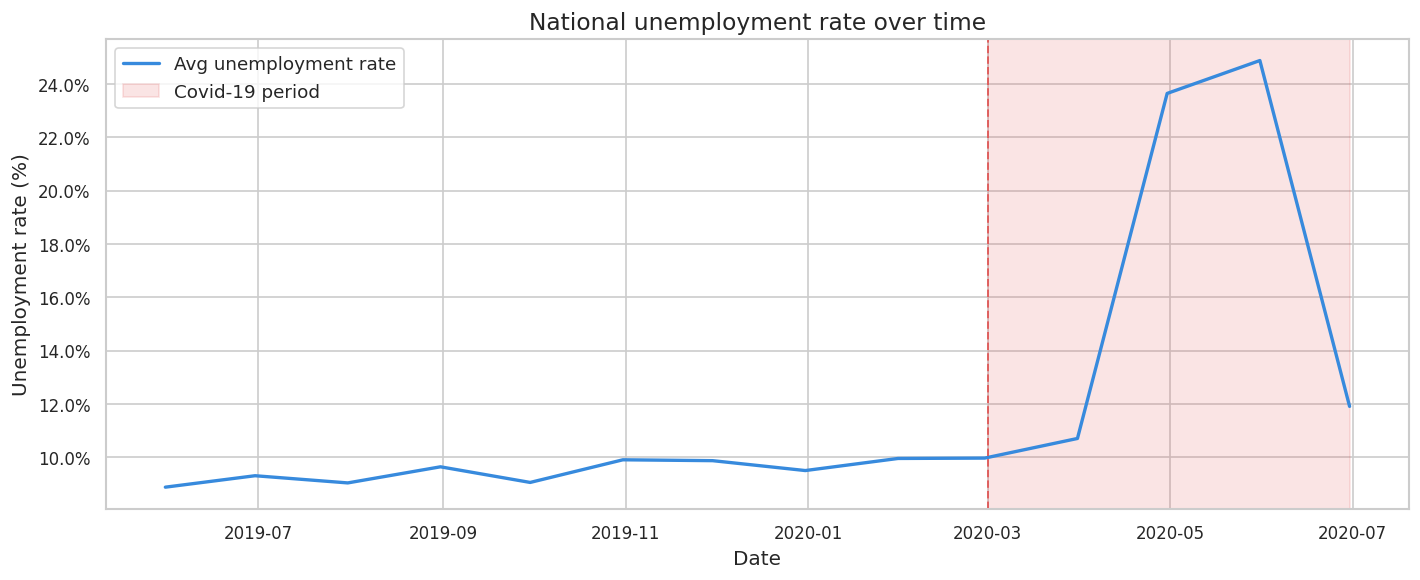

Saved: plot1_national_trend.png


In [6]:
# NATIONAL AVERAGE OVER TIME
monthly_avg = (
    df.groupby("date")["unemployment_rate"]
    .mean()
    .reset_index()
    .rename(columns={"unemployment_rate": "avg_rate"})
)

# Mark the Covid-19 period (March 2020 onward)
covid_start = pd.Timestamp("2020-03-01")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_avg["date"], monthly_avg["avg_rate"],
        color="#378ADD", linewidth=2, label="Avg unemployment rate")

# Shade Covid period
covid_data = monthly_avg[monthly_avg["date"] >= covid_start]
if not covid_data.empty:
    ax.axvspan(covid_start, monthly_avg["date"].max(),
               alpha=0.15, color="#E24B4A", label="Covid-19 period")
    ax.axvline(covid_start, color="#E24B4A",
               linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_title("National unemployment rate over time")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend()
plt.tight_layout()
plt.savefig("plot1_national_trend.png", dpi=150)
plt.show()
print("Saved: plot1_national_trend.png")




── Pre vs Post Covid-19 ──
 Pre-Covid avg: 9.51%
 Post-Covid avg: 17.77%
 Change : +8.26%


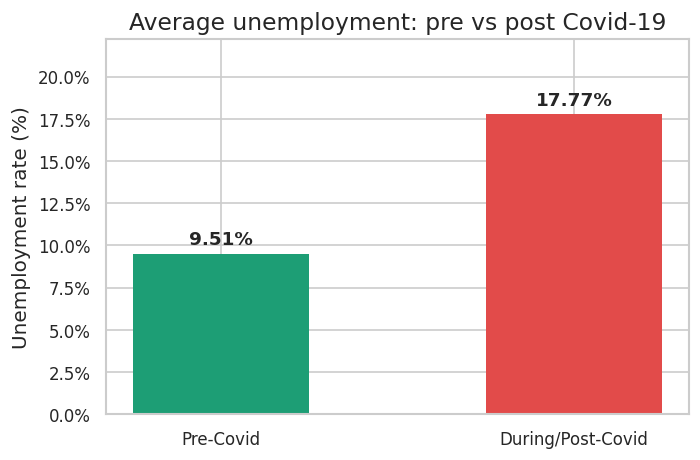

Saved: plot2_covid_impact.png


In [7]:
# COVID-19 IMPACT ANALYSIS
pre_covid = df[df["date"] < covid_start]["unemployment_rate"]
post_covid = df[df["date"] >= covid_start]["unemployment_rate"]

print("\n── Pre vs Post Covid-19 ──")
print(f" Pre-Covid avg: {pre_covid.mean():.2f}%")
print(f" Post-Covid avg: {post_covid.mean():.2f}%")
print(f" Change : +{post_covid.mean() - pre_covid.mean():.2f}%")

# Bar comparison
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Pre-Covid", "During/Post-Covid"]
values = [pre_covid.mean(), post_covid.mean()]
colors = ["#1D9E75", "#E24B4A"]
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="none")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3, f"{val:.2f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Average unemployment: pre vs post Covid-19")
ax.set_ylabel("Unemployment rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylim(0, max(values) * 1.25)
plt.tight_layout()
plt.savefig("plot2_covid_impact.png", dpi=150)
plt.show()
print("Saved: plot2_covid_impact.png")




── Average unemployment by region ──
          region  unemployment_rate
         Tripura          28.350357
         Haryana          26.283214
       Jharkhand          20.585000
           Bihar          18.918214
Himachal Pradesh          18.540357
           Delhi          16.495357
 Jammu & Kashmir          16.188571
      Chandigarh          15.991667
       Rajasthan          14.058214
   Uttar Pradesh          12.551429
          Punjab          12.031071
      Puducherry          10.215000
          Kerala          10.123929
      Tamil Nadu           9.284286
             Goa           9.274167
    Chhattisgarh           9.240357
     West Bengal           8.124643
       Telangana           7.737857
     Maharashtra           7.557500
  Andhra Pradesh           7.477143
  Madhya Pradesh           7.406429
          Sikkim           7.249412
       Karnataka           6.676071
         Gujarat           6.663929
     Uttarakhand           6.582963
           Assam          

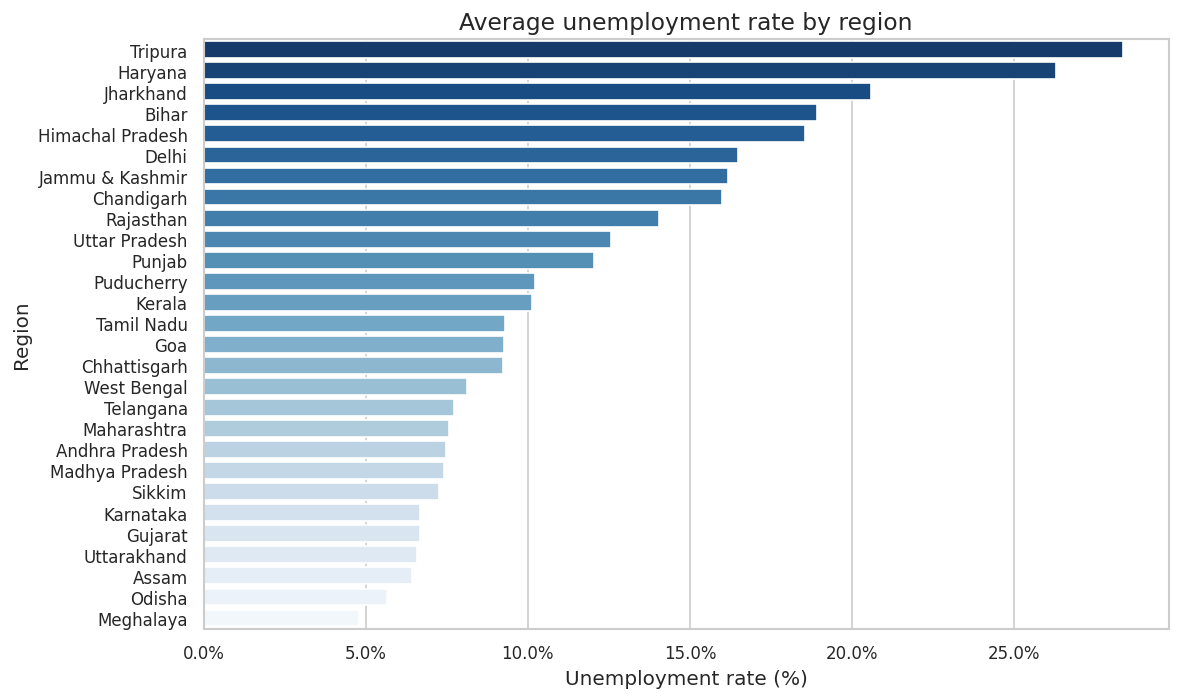

Saved: plot3_region_analysis.png


In [8]:
# REGION-WISE ANALYSIS
region_avg = (
    df.groupby("region")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print("\n── Average unemployment by region ──")
print(region_avg.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=region_avg, x="unemployment_rate", y="region",
            palette="Blues_r", ax=ax)
ax.set_title("Average unemployment rate by region")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("Region")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.savefig("plot3_region_analysis.png", dpi=150)
plt.show()
print("Saved: plot3_region_analysis.png")



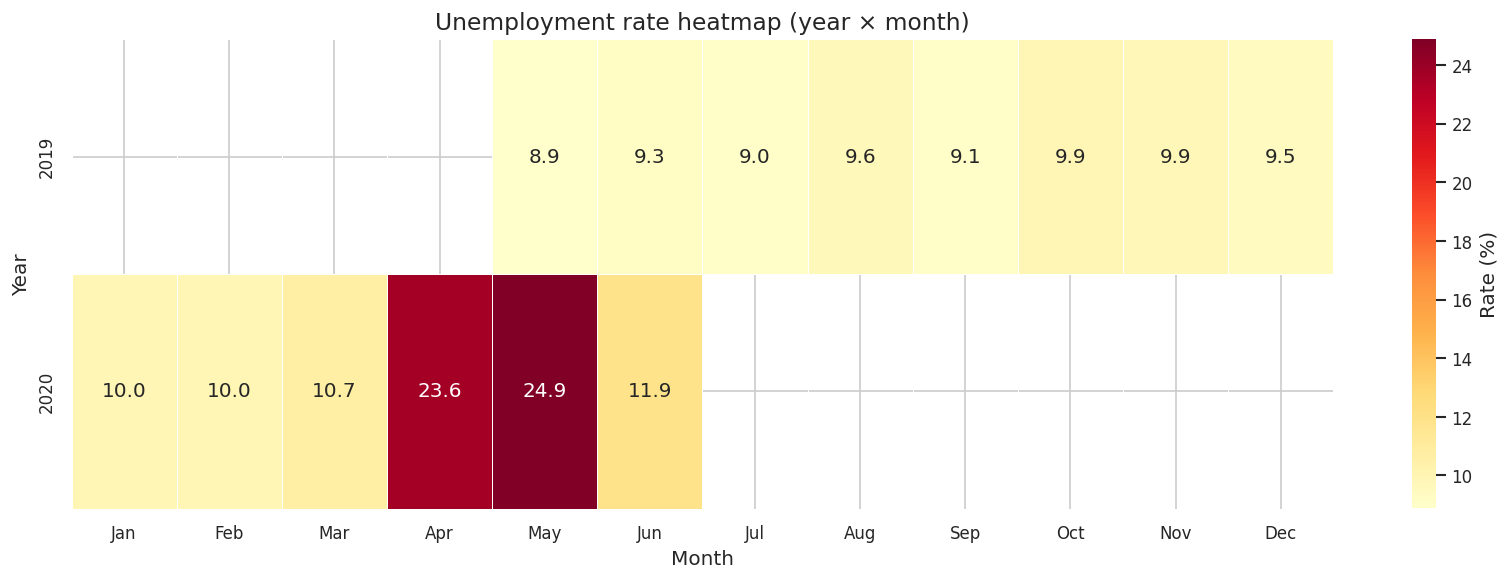

Saved: plot4_heatmap.png


In [9]:
# MONTHLY HEATMAP (Seasonal Trends)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

pivot = (
    df.groupby(["year", "month"])["unemployment_rate"]
    .mean()
    .unstack(level=1)
)
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Rate (%)"})
ax.set_title("Unemployment rate heatmap (year × month)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("plot4_heatmap.png", dpi=150)
plt.show()
print("Saved: plot4_heatmap.png")



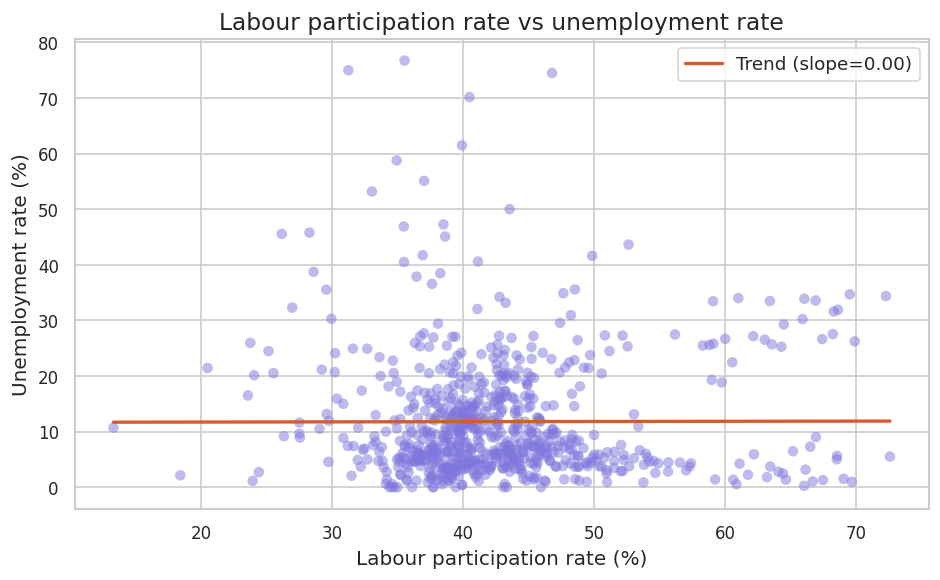

Saved: plot5_participation_vs_unemployment.png


In [10]:
# LABOUR PARTICIPATION vs UNEMPLOYMENT
if "labour_participation" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df["labour_participation"], df["unemployment_rate"],
               alpha=0.5, color="#7F77DD", edgecolors="none", s=40)
    # Trend line
    m, b = np.polyfit(df["labour_participation"], df["unemployment_rate"], 1)
    x_line = np.linspace(df["labour_participation"].min(),
                         df["labour_participation"].max(), 100)
    ax.plot(x_line, m * x_line + b, color="#D85A30",
            linewidth=2, label=f"Trend (slope={m:.2f})")
    ax.set_title("Labour participation rate vs unemployment rate")
    ax.set_xlabel("Labour participation rate (%)")
    ax.set_ylabel("Unemployment rate (%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("plot5_participation_vs_unemployment.png", dpi=150)
    plt.show()
    print("Saved: plot5_participation_vs_unemployment.png")



In [12]:
# KEY INSIGHTS
print("\n" + "="*55)
print(" KEY INSIGHTS")
print("="*55)
print(f" 1. Overall avg unemployment rate : {df['unemployment_rate'].mean():.2f}%")
print(f" 2. Peak unemployment rate : {df['unemployment_rate'].max():.2f}%")
print(f" Recorded on : {df.loc[df['unemployment_rate'].idxmax(), 'date'].strftime('%B %Y')}")
print(f" 3. Lowest unemployment rate : {df['unemployment_rate'].min():.2f}%")
print(f" 4. Pre-Covid avg : {pre_covid.mean():.2f}%")
print(f" 5. Post-Covid avg : {post_covid.mean():.2f}%")
print(f" 6. Covid-19 impact : +{post_covid.mean() - pre_covid.mean():.2f} percentage points")
print(f" 7. Hardest-hit region : {region_avg.iloc[0]['region']} ({region_avg.iloc[0]['unemployment_rate']:.2f}%)")
print(f" 8. Lowest-unemployment region : {region_avg.iloc[-1]['region']} ({region_avg.iloc[-1]['unemployment_rate']:.2f}%)")
print("="*55)


 KEY INSIGHTS
 1. Overall avg unemployment rate : 11.79%
 2. Peak unemployment rate : 76.74%
 Recorded on : April 2020
 3. Lowest unemployment rate : 0.00%
 4. Pre-Covid avg : 9.51%
 5. Post-Covid avg : 17.77%
 6. Covid-19 impact : +8.26 percentage points
 7. Hardest-hit region : Tripura (28.35%)
 8. Lowest-unemployment region : Meghalaya (4.80%)


In [13]:
from google.colab import files

files.download("plot1_national_trend.png")
files.download("plot2_covid_impact.png")
files.download("plot3_region_analysis.png")
files.download("plot4_heatmap.png")
files.download("plot5_participation_vs_unemployment.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>